<a href="https://colab.research.google.com/github/Afrinjahan/machine_learning/blob/main/ML_Lab06_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning — Lab Sheet 06
## Logistic Regression Implementation & Evaluation Metrics (Titanic Dataset)

**Brahmaputra International University | Department of CSE**

**Objectives:**
- Implement Logistic Regression for a real binary classification problem.
- Interpret model coefficients in terms of feature influence on the outcome.
- Evaluate using Confusion Matrix, Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Visualize and interpret the ROC curve and predicted probability distributions.

**Dataset:** Real Titanic passenger data (891 records), same dataset used in Labs 2 & 3.

### 0. Setup

In [ ]:
!pip install -q scikit-learn pandas matplotlib seaborn


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score, roc_curve, classification_report)


### 1. Load, Clean and Encode the Data

We reuse the same cleaning pipeline from Lab 2.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")
df_lab = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']].copy()

df_lab['age'] = df_lab['age'].fillna(df_lab['age'].median())
df_lab['embarked'] = df_lab['embarked'].fillna(df_lab['embarked'].mode()[0])
df_lab['sex'] = df_lab['sex'].map({'male': 1, 'female': 0})
df_lab = pd.get_dummies(df_lab, columns=['embarked'], prefix='embarked', drop_first=True)
df_lab.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


### 2. Train-Test Split, Scale, and Fit the Model

In [ ]:
X = df_lab.drop(columns=['survived'])
y = df_lab['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)

for f, c in zip(X.columns, model.coef_[0]):
    print(f'  {f}: {c:.4f}')
print(f'Intercept: {model.intercept_[0]:.4f}')


  pclass: -0.9287
  sex: -1.2696
  age: -0.5029
  sibsp: -0.2627
  parch: -0.0672
  fare: 0.0996
  embarked_Q: 0.0807
  embarked_S: -0.1718
Intercept: -0.6569


**Interpretation:** `sex` has the largest-magnitude coefficient — remember sex was encoded male=1, female=0, so a negative coefficient means being male strongly reduces the log-odds of survival, consistent with the historical "women and children first" pattern found in Lab 3's EDA.

### 3. Confusion Matrix and Core Metrics

In [ ]:
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}')


[[98 12]
 [23 46]]
Accuracy:  0.804
Precision: 0.793
Recall:    0.667
F1 Score:  0.724
ROC-AUC:   0.843


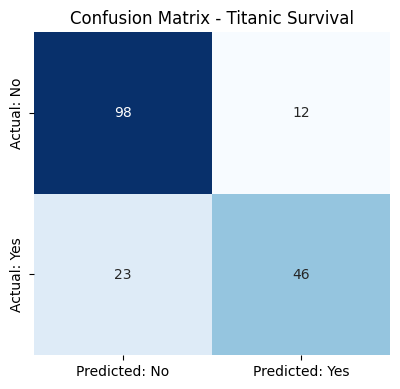

In [ ]:
fig, ax = plt.subplots(figsize=(4.6,4.2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: No','Predicted: Yes'], yticklabels=['Actual: No','Actual: Yes'], ax=ax)
ax.set_title('Confusion Matrix - Titanic Survival')
plt.show()


**Interpretation:** Recall is noticeably lower than Precision — the model is more conservative about predicting survival than it should be, missing about a third of actual survivors.

### 4. ROC Curve

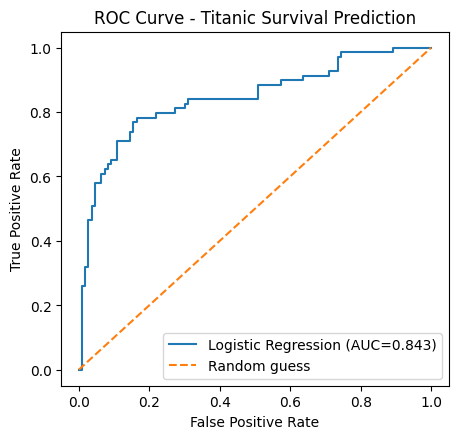

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(5,4.6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_proba):.3f})')
plt.plot([0,1],[0,1], linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Titanic Survival Prediction')
plt.legend()
plt.show()


An AUC around 0.84 means the model does a good job overall of ranking survivors above non-survivors across all possible thresholds, even though the chosen threshold of 0.5 produces imperfect recall — this is exactly why ROC-AUC is a threshold-independent view of performance.

### 5. Visualizing Coefficients and Predicted Probabilities

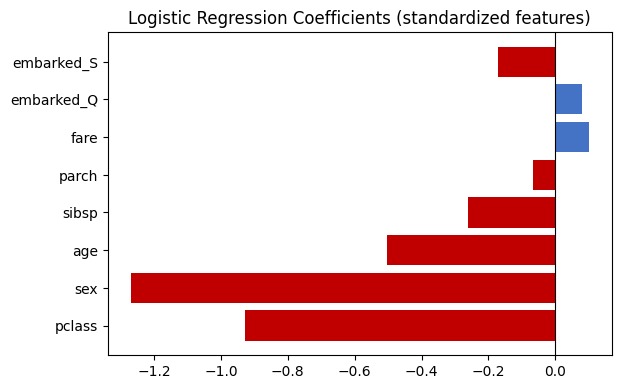

In [ ]:
coefs = model.coef_[0]
colors = ['#C00000' if c < 0 else '#4472C4' for c in coefs]
plt.figure(figsize=(6.5,4.2))
plt.barh(X.columns, coefs, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients (standardized features)')
plt.show()


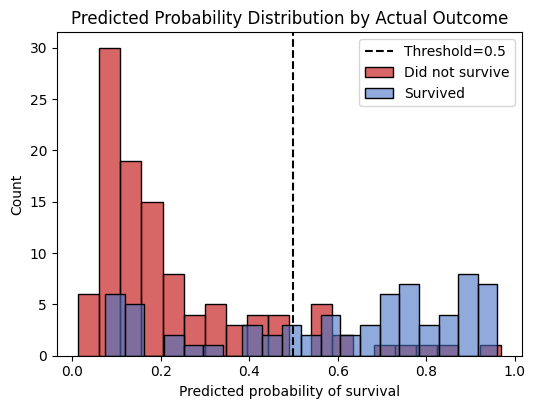

In [ ]:
plt.figure(figsize=(6,4.2))
for cls, label, color in [(0,'Did not survive','#C00000'),(1,'Survived','#4472C4')]:
    sns.histplot(y_proba[y_test.values==cls], bins=20, color=color, alpha=0.6, label=label)
plt.axvline(0.5, color='black', linestyle='--', label='Threshold=0.5')
plt.xlabel('Predicted probability of survival'); plt.ylabel('Count')
plt.title('Predicted Probability Distribution by Actual Outcome')
plt.legend()
plt.show()


### 6. Lab Exercise (To Be Submitted)

1. Try moving the decision threshold from 0.5 to 0.35. Recompute Precision, Recall, and F1 at this new threshold. Which metric improves, and which gets worse? Why?
2. Retrain the model using only `['pclass','sex','age']` (drop the other features). Compare the new Accuracy and ROC-AUC to the full-feature model. Was the extra complexity worth it?
3. Print `classification_report(y_test, y_pred)` and explain, in your own words, the difference between macro average and weighted average shown in the report.
4. The dataset has more non-survivors than survivors (imbalanced classes). Explain, using this lab's numbers, why Accuracy alone could be a misleading metric here.
5. Save your completed notebook and submit it (.ipynb) with all code, outputs, and answers added as new cells.

https://www.kaggle.com/code/devraai/fifa-2026-data-analysis-home-win-prediction

https://www.kaggle.com/datasets/yogeshm01/fifa-world-cup-2026-players-matches-dataset